# 08b. 최종 모델 평가 (Final Model Evaluation)

이 노트북은 `07b_disk_threshold_tuning.ipynb`에서 검증/캘리브레이션 데이터로 도출한 최적 운영점(임계값 $T$, 최소 알람 수 $n$, 윈도우 크기 $W$)을 **Held-out Test 데이터**에 적용하여 최종 평가를 수행합니다.

💡 **Grid Search 로직이 제거되고 핵심 평가 로직만 남긴 깔끔한 버전입니다.** 임계값 설정은 `config/final_eval_config.py` 에서 수동으로 직접 지정(`MANUAL_BEST_T`, `MANUAL_BEST_N`)하거나, 튜닝 결과를 자동으로 로드하게 설정할 수 있습니다.
또한 테스트 데이터로 앞서 생성한 **`test_with_failure_date.parquet`**를 사용합니다.

## 1. 환경 설정 및 라이브러리 로드

In [49]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import json
from pathlib import Path

import config.final_eval_config as cfg
from src.eval_core import (
    load_saved_ensemble,
    prepare_disk_level_data,
    evaluate_detailed_disk_point,
    plot_detailed_disk_analysis,
    get_detailed_disk_records
)

import matplotlib.font_manager as fm
def set_korean_font():
    for name in ["Malgun Gothic", "NanumGothic", "AppleGothic", "DejaVu Sans"]:
        if any(name.lower() in f.name.lower() for f in fm.fontManager.ttflist):
            plt.rcParams["font.family"] = name
            break
    plt.rcParams["axes.unicode_minus"] = False

set_korean_font()
print("✅ 환경 설정 및 라이브러리 로드 완료")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ 환경 설정 및 라이브러리 로드 완료


## 2. 최종 모델, 최적 임계값 및 Test 데이터 로드

In [50]:
print("🔄 최종 모델 및 최적 임계값 로드 중...")
artifacts = load_saved_ensemble(cfg, require_threshold=True)
feature_cols = artifacts["feature_cols"]
ensemble = artifacts["ensemble"]

# 수동 오버라이드 (config에 설정된 경우 우선 적용)
BEST_T = 0.9590
BEST_N = 1
ALARM_WINDOW = 0



print(f"✅ 모델 로드 완료: {len(feature_cols)}개 피처")
print(f"🎯 최종 운영점: 단일 임계값 T = {BEST_T:.4f}")

print("\n🔄 Test 데이터 로드 중...")
test_path = Path(cfg.TEST_PATH)
df_test = pd.read_parquet(test_path)
print(f"✅ 데이터 로드 완료: {len(df_test):,} 행 (파일: {test_path.name})")

🔄 최종 모델 및 최적 임계값 로드 중...

[Data Path Contract]
  [OK] model save directory: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4
  [OK] feature columns: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4\feature_cols.json (591 bytes)
  [OK] best threshold metadata: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4\best_threshold.json (679 bytes)
[Model Artifact Contract]
  model_dir: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4
  feature_cols: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4\feature_cols.json (27 features)
  threshold_path: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4\best_threshold.json
  threshold: 0.972027
  threshold_source_val_calib: C:\Workspace\06_ML_projdect\26_1_COIN\data\split_group_stratified\val_calib.parquet
  model: subset_00.pkl (9,539,044 bytes)
  model: subset_01.pkl (9,555,780 bytes)
  model: subset_02.pkl (9,557,204 bytes)
  model:

## 3. 앙상블 예측 수행 및 디스크 단위 데이터 구성

In [51]:
# 테스트 파일명에 따라 독립적인 캐시 파일명을 사용합니다.
# (예: test.parquet -> test_probs.npy, test_with_failure_date.parquet -> test_with_failure_date_probs.npy)
cache_filename = f"{test_path.stem}_probs.npy"
cache_path = os.path.join(cfg.MODEL_SAVE_DIR, cache_filename)

if os.path.exists(cache_path):
    print(f"♻️ '{cache_filename}' 캐시된 예측 확률 파일 로드 중...")
    y_prob = np.load(cache_path)
    
    # 만약 파일은 같은데 행 수가 미세하게 다르다면 (거의 발생하지 않지만 안전장치)
    if len(y_prob) != len(df_test):
        print("⚠️ 동일한 파일명이지만 데이터 크기가 다릅니다. 캐시를 덮어쓰고 다시 예측합니다.")
        y_prob = ensemble.predict_proba(df_test, feature_cols, verbose=True)
        np.save(cache_path, y_prob)
    else:
        print(f"✅ 로드 완료: {len(y_prob):,}행")
else:
    t0 = time.perf_counter()
    print("🔄 앙상블 예측 수행 중 (최초 1회만 실행)...")
    y_prob = ensemble.predict_proba(df_test, feature_cols, verbose=True)
    np.save(cache_path, y_prob)
    print(f"✅ 예측 완료 및 캐시 저장 완료! 소요 시간: {time.perf_counter() - t0:.1f}초")

df_test['y_prob'] = y_prob

print("\n🔄 시리얼별 정렬 및 그룹화 데이터 작성 중...")
disks_data, n_failed_disks, n_normal_disks = prepare_disk_level_data(
    df_test, y_prob, target_col=cfg.TARGET_COL, serial_col=cfg.SERIAL_COL, date_col=cfg.DATE_COL
)
print(f"✅ 총 {len(disks_data):,}개 디스크 구성 완료 (Failed: {n_failed_disks:,}, Normal: {n_normal_disks:,})")


♻️ 'test_with_failure_date_probs.npy' 캐시된 예측 확률 파일 로드 중...
✅ 로드 완료: 15,696,223행

🔄 시리얼별 정렬 및 그룹화 데이터 작성 중...
✅ 총 7,382개 디스크 구성 완료 (Failed: 1,127, Normal: 6,255)


## 4. 최종 모델 평가 및 세부 지표 산출

🎯 도출된 최적 운영점 적용: 임계값 T = 0.9261, 최소 알람 수 n = 2 (window_size=14)

[OK] 개별 디스크 세부 통계 (test) CSV 저장 완료: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4\best_disk_lead_time_distribution_test.csv

  [최적 운영점 최종 스냅샷] T = 0.9261, n = 2 (Rolling W=14)
  [기본 탐지 성능]
  Disk Recall (TPR)             : 41.53%
  Disk FAR (FPR)                : 1.31%
  Disk Specificity (TNR)        : 98.69%
  Precision (PPV)               : 85.09%
  Disk Accuracy                 : 89.96%

  [복합 평가지표 (F-Scores & AUC)]
  Disk F1 Score                 : 0.5581
  Disk F2 Score (Recall 중시)   : 0.4626
  Disk ROC-AUC (Max Prob 기준)  : 0.8241
  Disk PR-AUC (Max Prob 기준)   : 0.6857
  Brier Score (Calibration)     : 0.13793

  [시계열 및 알람 안정성 지표]
  Average Lead Time (리드타임)   : 124.55일
  Alarm Persistence (지속도)    : 56.53%
  Failure Window Hit Rate       : 34.16%
  Alarm Density Ratio (정상대비) : 21.90배
  Average Consecutive Length    : 0.90일
  Average Alert Burden          : 1.33일

[OK] 최종 평가 메타데이터 JSON 저장 완료: C:

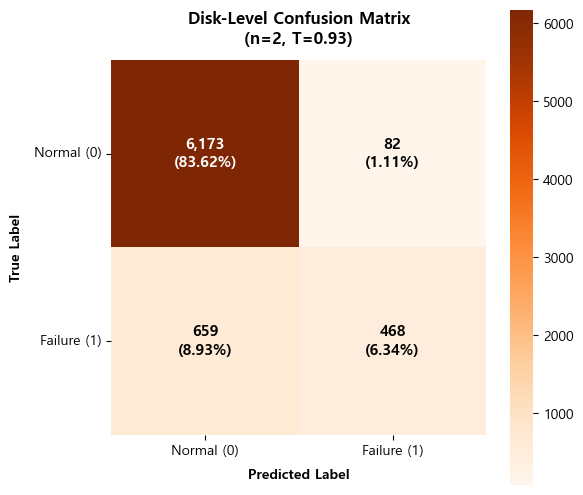

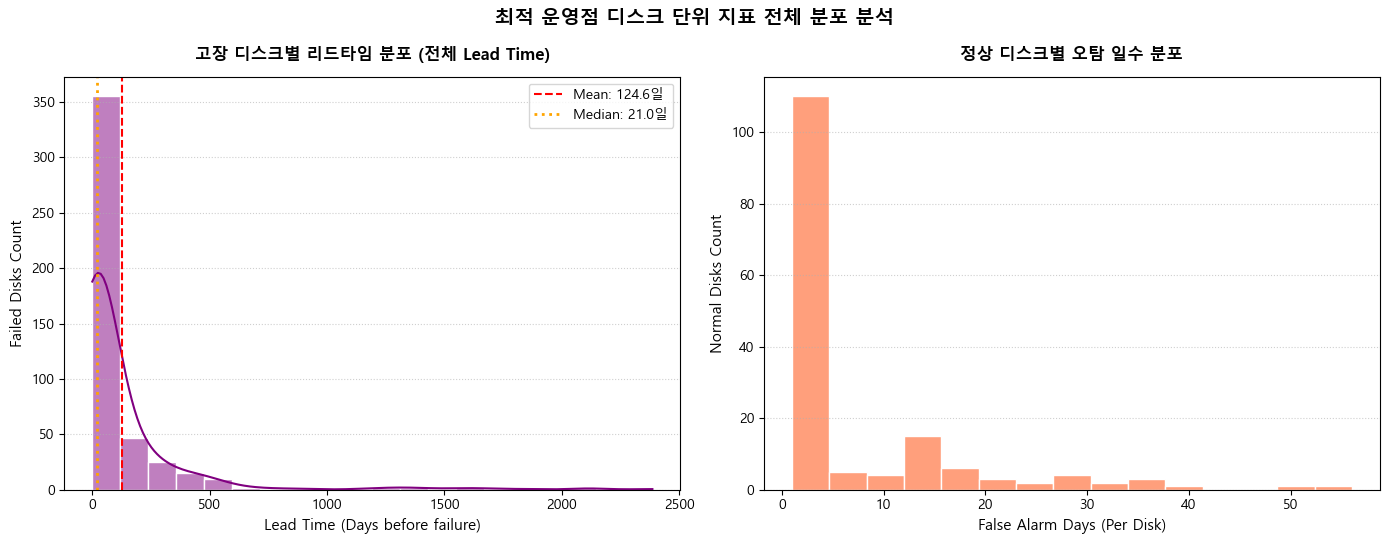

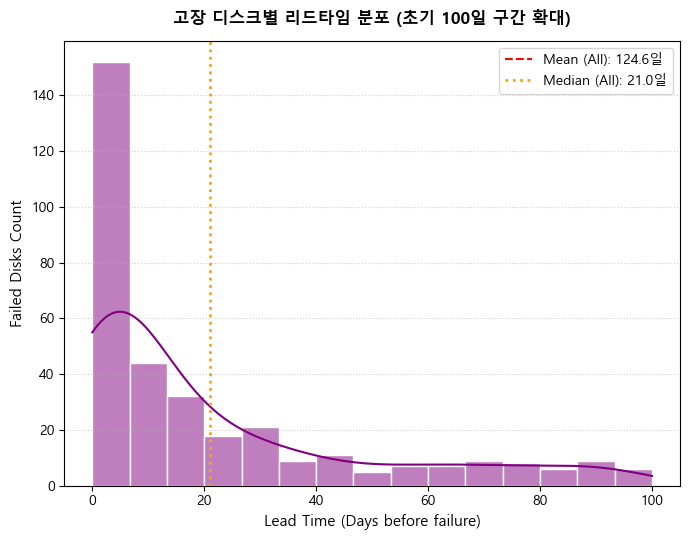

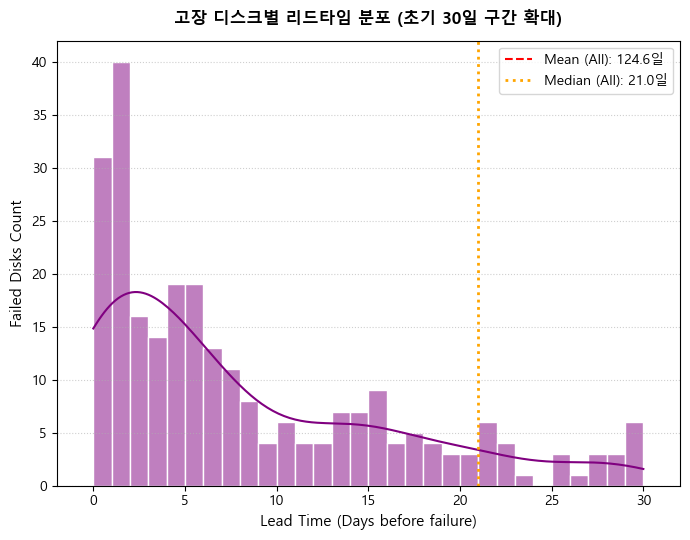

In [52]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, fbeta_score

print(f"🎯 도출된 최적 운영점 적용: 단일 임계값 T = {BEST_T:.4f}")
stats = evaluate_detailed_disk_point(disks_data, BEST_T, 1, n_failed_disks, n_normal_disks, window_size=0)

# 코어 함수를 통해 세부 통계 데이터프레임 추출
df_best_disk = get_detailed_disk_records(disks_data, BEST_T, 1, window_size=0)

best_disk_csv_path = os.path.join(cfg.MODEL_SAVE_DIR, 'best_disk_lead_time_distribution_test.csv')
df_best_disk.to_csv(best_disk_csv_path, index=False, encoding='utf-8-sig')
print(f"\n[OK] 개별 디스크 세부 통계 (test) CSV 저장 완료: {best_disk_csv_path}")

# --- 추가된 혼동행렬 기반 지표들 ---
y_true_disks = df_best_disk['is_failed'].values
y_pred_disks = df_best_disk['is_alarmed'].values

tp = int(((y_true_disks == 1) & (y_pred_disks == 1)).sum())
fn = int(((y_true_disks == 1) & (y_pred_disks == 0)).sum())
fp = int(((y_true_disks == 0) & (y_pred_disks == 1)).sum())
tn = int(((y_true_disks == 0) & (y_pred_disks == 0)).sum())

# Disk Level Probabilities (최대 확률 기준)
max_probs = [np.max(d['probs']) for d in disks_data]
roc_auc = roc_auc_score(y_true_disks, max_probs)
pr_auc = average_precision_score(y_true_disks, max_probs)

disk_f1 = f1_score(y_true_disks, y_pred_disks)
disk_f2 = fbeta_score(y_true_disks, y_pred_disks, beta=2) # Recall에 더 가중치를 둔 F2 Score
disk_accuracy = (tp + tn) / (tp + fn + fp + tn)
disk_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

print("\n" + "=" * 65)
print(f"  [최적 운영점 최종 스냅샷] T = {BEST_T:.4f}, n = {BEST_N} (Rolling W={ALARM_WINDOW})")
print("=" * 65)
print(f"  [기본 탐지 성능]")
print(f"  Disk Recall (TPR)             : {stats['recall']*100:.2f}%")
print(f"  Disk FAR (FPR)                : {stats['far']*100:.2f}%")
print(f"  Disk Specificity (TNR)        : {disk_specificity*100:.2f}%")
print(f"  Precision (PPV)               : {stats['precision']*100:.2f}%")
print(f"  Disk Accuracy                 : {disk_accuracy*100:.2f}%")
print(f"\n  [복합 평가지표 (F-Scores & AUC)]")
print(f"  Disk F1 Score                 : {disk_f1:.4f}")
print(f"  Disk F2 Score (Recall 중시)   : {disk_f2:.4f}")
print(f"  Disk ROC-AUC (Max Prob 기준)  : {roc_auc:.4f}")
print(f"  Disk PR-AUC (Max Prob 기준)   : {pr_auc:.4f}")
print(f"  Brier Score (Calibration)     : {stats['calibration']:.5f}")
print(f"\n  [시계열 및 알람 안정성 지표]")
print(f"  Average Lead Time (리드타임)   : {stats['lead_time']:.2f}일")
print(f"  Alarm Persistence (지속도)    : {stats['persistence']*100:.2f}%")
print(f"  Failure Window Hit Rate       : {stats['fw_hit_rate']*100:.2f}%")
print(f"  Alarm Density Ratio (정상대비) : {stats['density_ratio']:.2f}배")
print(f"  Average Consecutive Length    : {stats['consec_len']:.2f}일")
print(f"  Average Alert Burden          : {stats['alert_burden']:.2f}일")
print("=" * 65)

final_eval_meta = {
    "threshold": BEST_T, "min_alarms": BEST_N, "window_size": ALARM_WINDOW,
    "test_path": cfg.TEST_PATH, "n_failed_disks": n_failed_disks, "n_normal_disks": n_normal_disks,
    "metrics": {
        "recall": float(stats["recall"]), "far": float(stats["far"]), "precision": float(stats["precision"]),
        "specificity": float(disk_specificity), "accuracy": float(disk_accuracy),
        "f1_score": float(disk_f1), "f2_score": float(disk_f2),
        "roc_auc": float(roc_auc), "pr_auc": float(pr_auc),
        "calibration": float(stats["calibration"]), "lead_time": float(stats["lead_time"]),
        "persistence": float(stats["persistence"]), "fw_hit_rate": float(stats["fw_hit_rate"]),
        "density_ratio": float(stats["density_ratio"]), "consec_len": float(stats["consec_len"]),
        "alert_burden": float(stats["alert_burden"])
    },
    "confusion_matrix": { "tp": tp, "fn": fn, "fp": fp, "tn": tn },
    "created_at": time.strftime("%Y-%m-%dT%H:%M:%S")
}
meta_path = os.path.join(cfg.MODEL_SAVE_DIR, "final_evaluation.json")
with open(meta_path, "w", encoding="utf-8") as f: 
    json.dump(final_eval_meta, f, ensure_ascii=False, indent=2)
print(f"\n[OK] 최종 평가 메타데이터 JSON 저장 완료: {meta_path}\n")

plot_detailed_disk_analysis(stats, df_best_disk, tp, fn, fp, tn)
